# Band structure and DOS for Si

Ref:
    https://wiki.fysik.dtu.dk/ase/ase/dft/kpoints.html

In [1]:
import numpy as np
from qepy.calculator import QEpyCalculator
from qepy.io import QEInput

In [2]:
from ase.io.trajectory import Trajectory
from ase.build import bulk
from ase import Atoms
import matplotlib.pyplot as plt
from dftpy.formats import download_files

In [3]:
qe_options = {
    '&control': {
        'calculation': "'scf'",
        'prefix': "'tmp'",
        'pseudo_dir': "'./'"},
    '&system': {
        'ibrav' : 0,
        'ecutwfc': 20,
        'ecutrho': 200},
    '&electrons': {
        'conv_thr' : 1.0e-8},
     'atomic_species': ['Si 28.085 Si.pz-vbc.UPF'],
     'k_points automatic': [' 9 9 9 0 0 0'],
}

In [4]:
additional_files = {
    'Si.pz-vbc.UPF' : 'https://pseudopotentials.quantum-espresso.org/upf_files/Si.pz-vbc.UPF',
}
download_files(additional_files)

In [5]:
atoms = bulk('Si', a=5.431)

In [6]:
calc = QEpyCalculator(qe_options=qe_options, logfile='tmp.out')
atoms.calc=calc

## Run a ground state calculation

In [7]:
energy = atoms.get_potential_energy()
efermi = calc.get_fermi_level()
print(efermi)

6.053474430208154


## DOS with a fine mesh of $k$-points $\in$ FBZ

In [8]:
qe_options['k_points automatic']= ['12 12 12 0 0 0']
energies, dos =  atoms.calc.get_dos(qe_options, width=0.6)

Text(-1.5, 1.5, 'Fermi level')

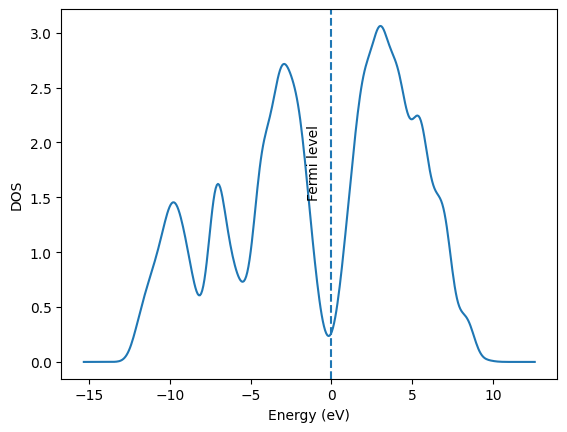

In [9]:
plt.plot(energies, dos)
plt.axvline(x=0, ls='--'); plt.xlabel("Energy (eV)"); plt.ylabel("DOS"); 
plt.text(x=-1.5,y=1.5,rotation='vertical',s='Fermi level')

## Band structure with ASE bandpath

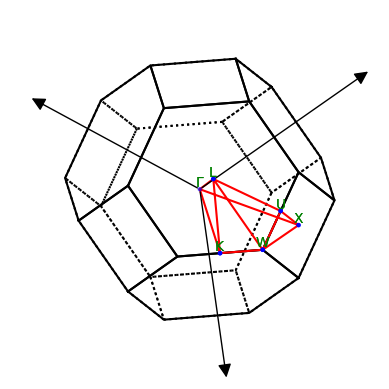

FCC(a=5.431)
  Variant name: FCC
  Special point names: GKLUWX
  Default path: GXWKGLUWLK,UX

  Special point coordinates:
    G   0.0000  0.0000  0.0000
    K   0.3750  0.3750  0.7500
    L   0.5000  0.5000  0.5000
    U   0.6250  0.2500  0.6250
    W   0.5000  0.2500  0.7500
    X   0.5000  0.0000  0.5000



In [10]:
lat = atoms.cell.get_bravais_lattice()
lat.plot_bz(show=True)
print(lat.description())

In [11]:
path = atoms.cell.bandpath('LGXU,KG',npoints=61)

In [26]:
qe_options['&system']['nbnd']=8
band = atoms.calc.get_band_structure(qe_options, kpts=path, reference=efermi)
band = band.subtract_reference()

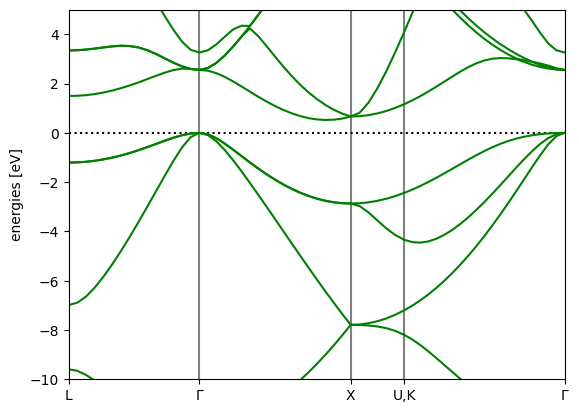

In [28]:
bp=band.plot()

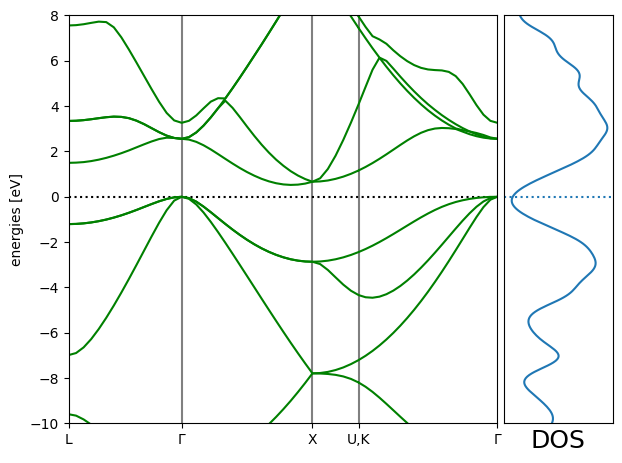

In [29]:
fig = plt.figure()
ax = fig.add_axes([.12, .07, .67, .85])

emin = -10.0; emax = 8.0

bands = band.subtract_reference()
bands.plot(ax=ax, emin=emin, emax=emax)

dosax = fig.add_axes([.8, .07, .17, .85])
dosax.plot(dos, energies)
dosax.axhline(y=0, ls=':')

dosax.set_ylim(emin, emax)
dosax.set_xlim(0, None)
dosax.set_yticks([])
dosax.set_xticks([])
dosax.set_xlabel("DOS", fontsize=18);